In [108]:
import random
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_formats='retina'
plt.style.use(random.choice(plt.style.available))

import numpy as np
import pandas as pd

import warnings


from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.simplefilter("ignore", InterpolationWarning)

from sklearn.preprocessing import power_transform
from sklearn import set_config

set_config(transform_output="pandas")


# ADF test is used to determine the presence of unit root in the series, and hence helps in understand if the series is stationary or not. The null and alternate hypothesis of this test are:
# Null Hypothesis: The series has a unit root.
# Alternate Hypothesis: The series has no unit root.
# If the null hypothesis fails to be rejected, this test may provide evidence that the series is non-stationary.
def adf_test(timeseries, autolag="AIC"):
    from statsmodels.tsa.stattools import adfuller

    # "AIC" (Akaike Information Criterion):
    # This option selects the lag length that minimizes the AIC.
    # The AIC is a measure that balances the goodness of fit of a statistical model with its complexity.
    # Lower AIC values generally indicate a better model.
    # "BIC" (Bayesian Information Criterion):
    # Similar to AIC, this option chooses the lag length that minimizes the BIC.
    # The BIC also balances model fit and complexity, but it tends to penalize complex models more heavily than the AIC.
    # "t-stat" (t-statistic):
    # This method starts with the maximum lag length (maxlag) and iteratively reduces it.
    # It stops when the t-statistic of the last lag becomes statistically significant (typically at a 5% significance level).
    # This approach focuses on the statistical significance of the individual lags.
    dftest = adfuller(timeseries.dropna(), autolag=autolag)
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value

    dfoutput[autolag] = dftest[5]

    dfoutput.name = "Results of Dickey-Fuller Test"

    if (dftest[1] < 0.05) & (dftest[4]["5%"] > dftest[0]):
        print(
            "\u001b[32mConclusion: The data is stationary (Reject the null hypothesis)\u001b[0m"
        )
    else:
        print(
            "\x1b[31mConclusion: The data is not stationary (Fail to reject the null hypothesis)\x1b[0m"
        )
    return dfoutput


# KPSS is another test for checking the stationarity of a time series. The null and alternate hypothesis for the KPSS test are opposite that of the ADF test.
# Null Hypothesis: The process is trend stationary.
# Alternate Hypothesis: The series has a unit root (series is not stationary).
def kpss_test(timeseries, regression="c"):
    from statsmodels.tsa.stattools import kpss

    kpsstest = kpss(timeseries.dropna(), regression=regression, nlags="auto")
    kpssoutput = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpssoutput["Critical Value (%s)" % key] = value

    kpssoutput.name = "Results of KPSS Test"

    if (kpsstest[1] < 0.05) & (kpsstest[3]["5%"] > kpsstest[0]):
        print(
            "\x1b[31mConclusion: The data is not stationary (Reject the null hypothesis)\x1b[0m"
        )

    else:
        print(
            "\u001b[32mConclusion: The data is stationary (Fail to reject the null hypothesis)\u001b[0m"
        )

    return kpssoutput

In [109]:
air_passengers = pd.read_csv("AirPassengers.csv")
air_passengers['Month'] = pd.to_datetime(air_passengers['Month']) # convert to datetime
air_passengers.set_index("Month", inplace=True) # set index based on time labels
air_passengers


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [110]:
air_passengers = air_passengers.resample("MS").sum() # resample by month start
air_passengers.index.freq = "MS"
air_passengers["#Passengers_ln"] = np.log(air_passengers["#Passengers"])
air_passengers

,#Passengers,#Passengers_ln
Month,,
1949-01-01,112,4.718499
1949-02-01,118,4.770685
1949-03-01,132,4.882802
1949-04-01,129,4.859812
1949-05-01,121,4.795791
...,...,...
1960-08-01,606,6.406880
1960-09-01,508,6.230481
1960-10-01,461,6.133398


From time-series-1 homework, we find d = 2

In [111]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(air_passengers["#Passengers_ln"].dropna(), extrapolate_trend="freq")
seasonals = decomposition.seasonal
trends = decomposition.trend

no_seasonal_trend = air_passengers["#Passengers_ln"] - seasonals - trends

air_passengers["#Passengers_ln_no_seasonal_trend"] = no_seasonal_trend
air_passengers

,#Passengers,#Passengers_ln,#Passengers_ln_no_seasonal_trend
Month,,,
1949-01-01,112,4.718499,0.023415
1949-02-01,118,4.770685,0.090092
1949-03-01,132,4.882802,0.064010
1949-04-01,129,4.859812,0.064125
1949-05-01,121,4.795791,-0.005676
...,...,...,...
1960-08-01,606,6.406880,0.025812
1960-09-01,508,6.230481,-0.016449
1960-10-01,461,6.133398,0.014392


In [112]:
adf_test(air_passengers["#Passengers_ln_no_seasonal_trend"].diff().diff())

Conclusion: The data is stationary (Reject the null hypothesis)


Test Statistic                -8.692822e+00
p-value                        3.997804e-14
#Lags Used                     1.300000e+01
Number of Observations Used    1.280000e+02
Critical Value (1%)           -3.482501e+00
Critical Value (5%)           -2.884398e+00
Critical Value (10%)          -2.578960e+00
AIC                           -5.047485e+02
Name: Results of Dickey-Fuller Test, dtype: float64

In [113]:
kpss_test(air_passengers["#Passengers_ln_no_seasonal_trend"].diff().diff())

Conclusion: The data is stationary (Fail to reject the null hypothesis)


Test Statistic            0.073449
p-value                   0.100000
Lags Used                15.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
Name: Results of KPSS Test, dtype: float64

# Use “plot_pacf” and “plot_acf” to get the “p” and “q” values respectively.

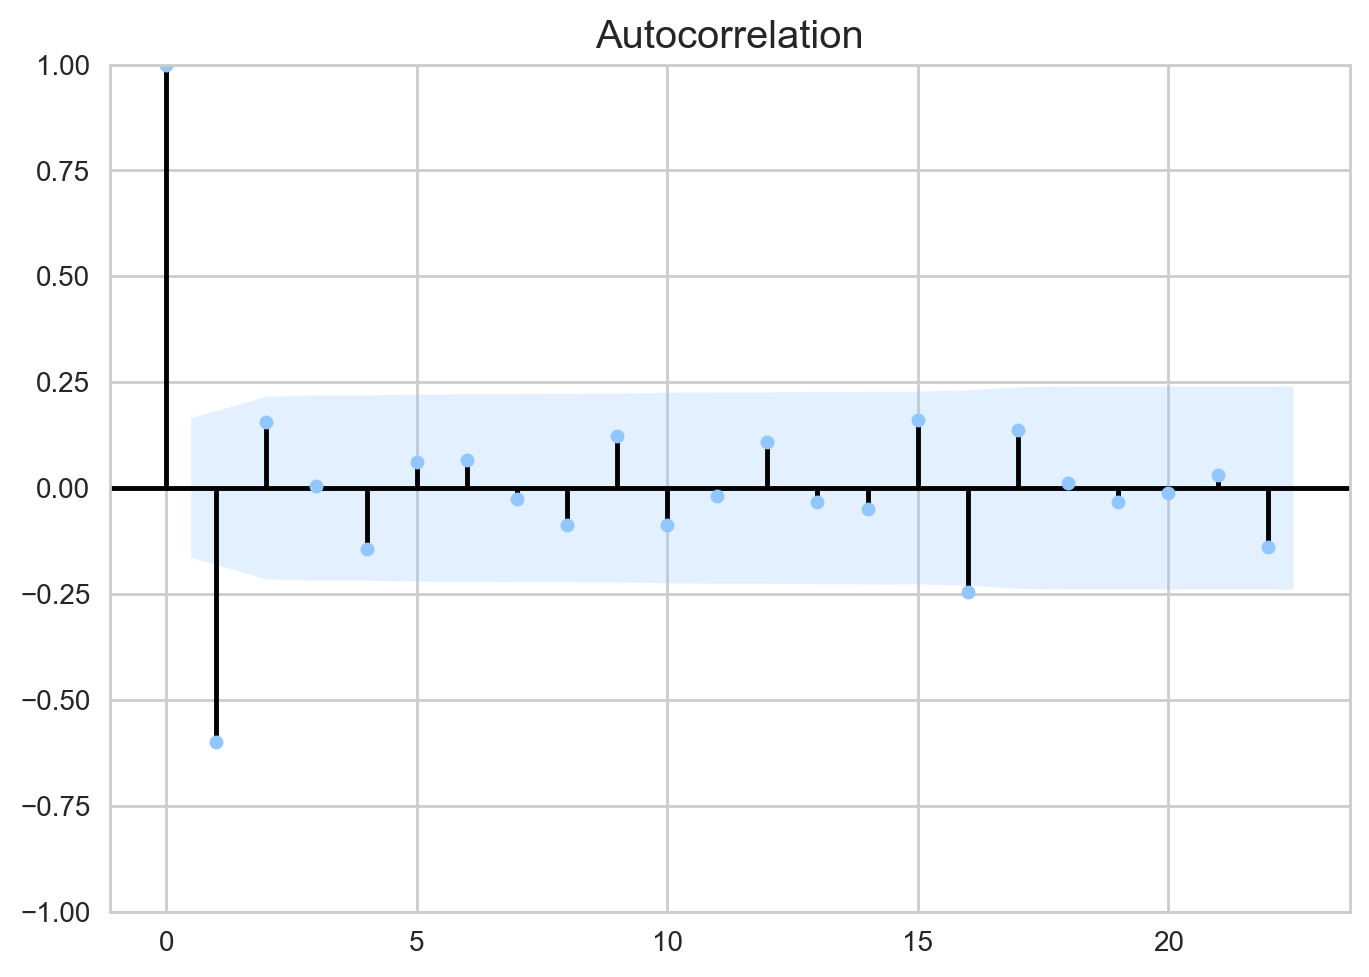

In [114]:
plot_acf(air_passengers["#Passengers_ln_no_seasonal_trend"].diff().diff().dropna());

We find q = 1

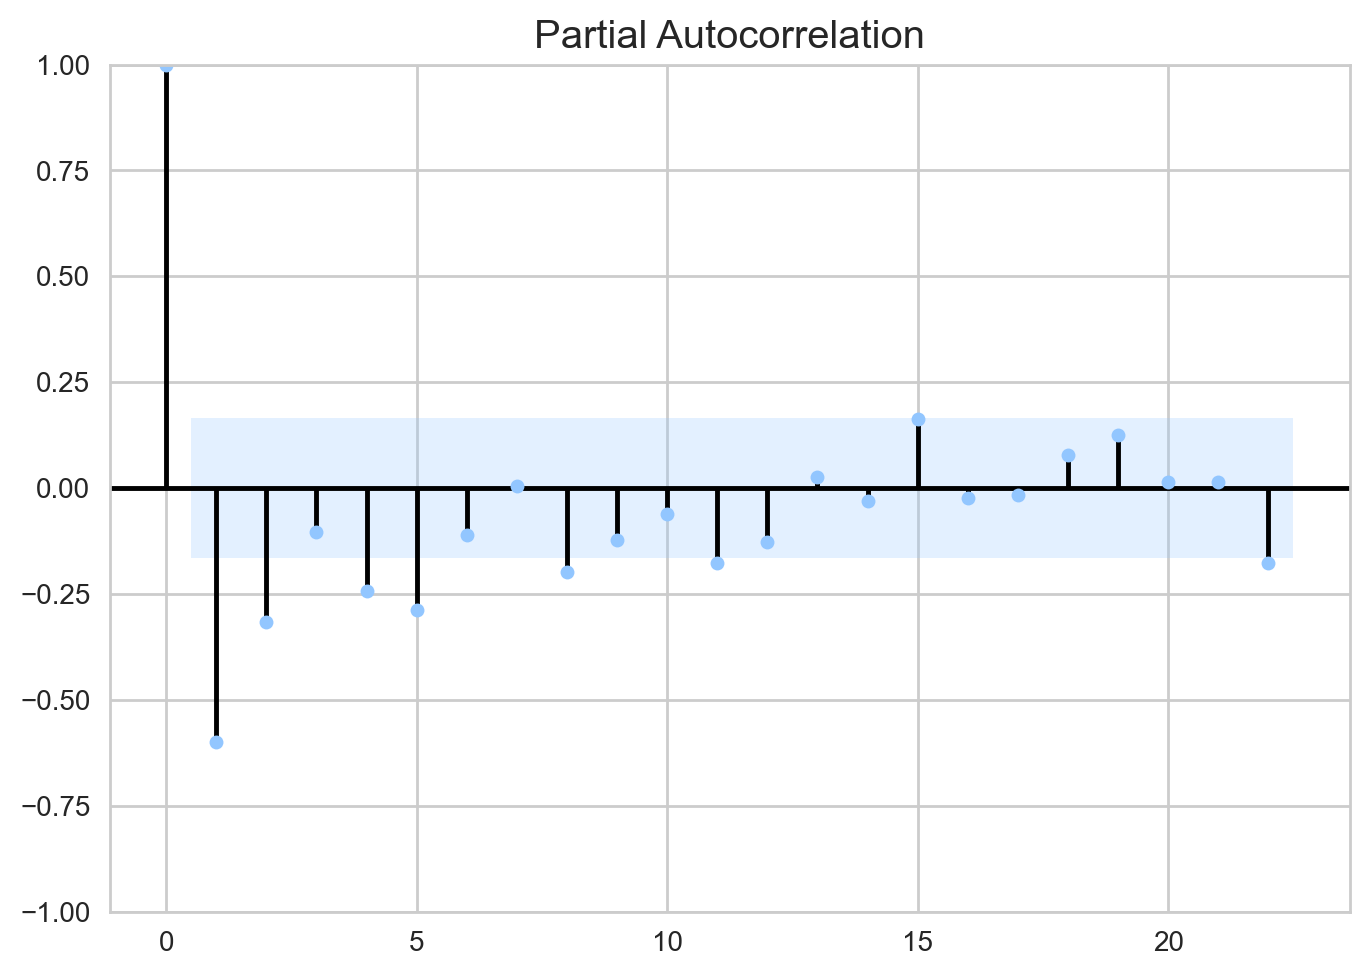

In [115]:
plot_pacf(air_passengers["#Passengers_ln_no_seasonal_trend"].diff().diff().dropna());

We find p = 2

In [116]:
p = 2
d = 2
q = 1

# Build an ARIMA model based on the “p” and “q” values obtained from above and get the RMSE.

In [117]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split

train, test = train_test_split(air_passengers["#Passengers_ln_no_seasonal_trend"], test_size=12, shuffle=False)
display(train.tail(12))
print(train.shape)
display(test.head(12))
print(test.shape)


Month
1959-01-01   -0.013755
1959-02-01   -0.051321
1959-03-01   -0.019847
1959-04-01   -0.024546
1959-05-01    0.024871
1959-06-01    0.005026
1959-07-01    0.037916
1959-08-01    0.054819
1959-09-01    0.003022
1959-10-01    0.003766
1959-11-01    0.018980
1959-12-01    0.007495
Freq: MS, Name: #Passengers_ln_no_seasonal_trend, dtype: float64

(132,)


Month
1960-01-01    0.005985
1960-02-01   -0.044499
1960-03-01   -0.112720
1960-04-01    0.004900
1960-05-01    0.022452
1960-06-01    0.019497
1960-07-01    0.052521
1960-08-01    0.025812
1960-09-01   -0.016449
1960-10-01    0.014392
1960-11-01   -0.018661
1960-12-01   -0.039407
Freq: MS, Name: #Passengers_ln_no_seasonal_trend, dtype: float64

(12,)


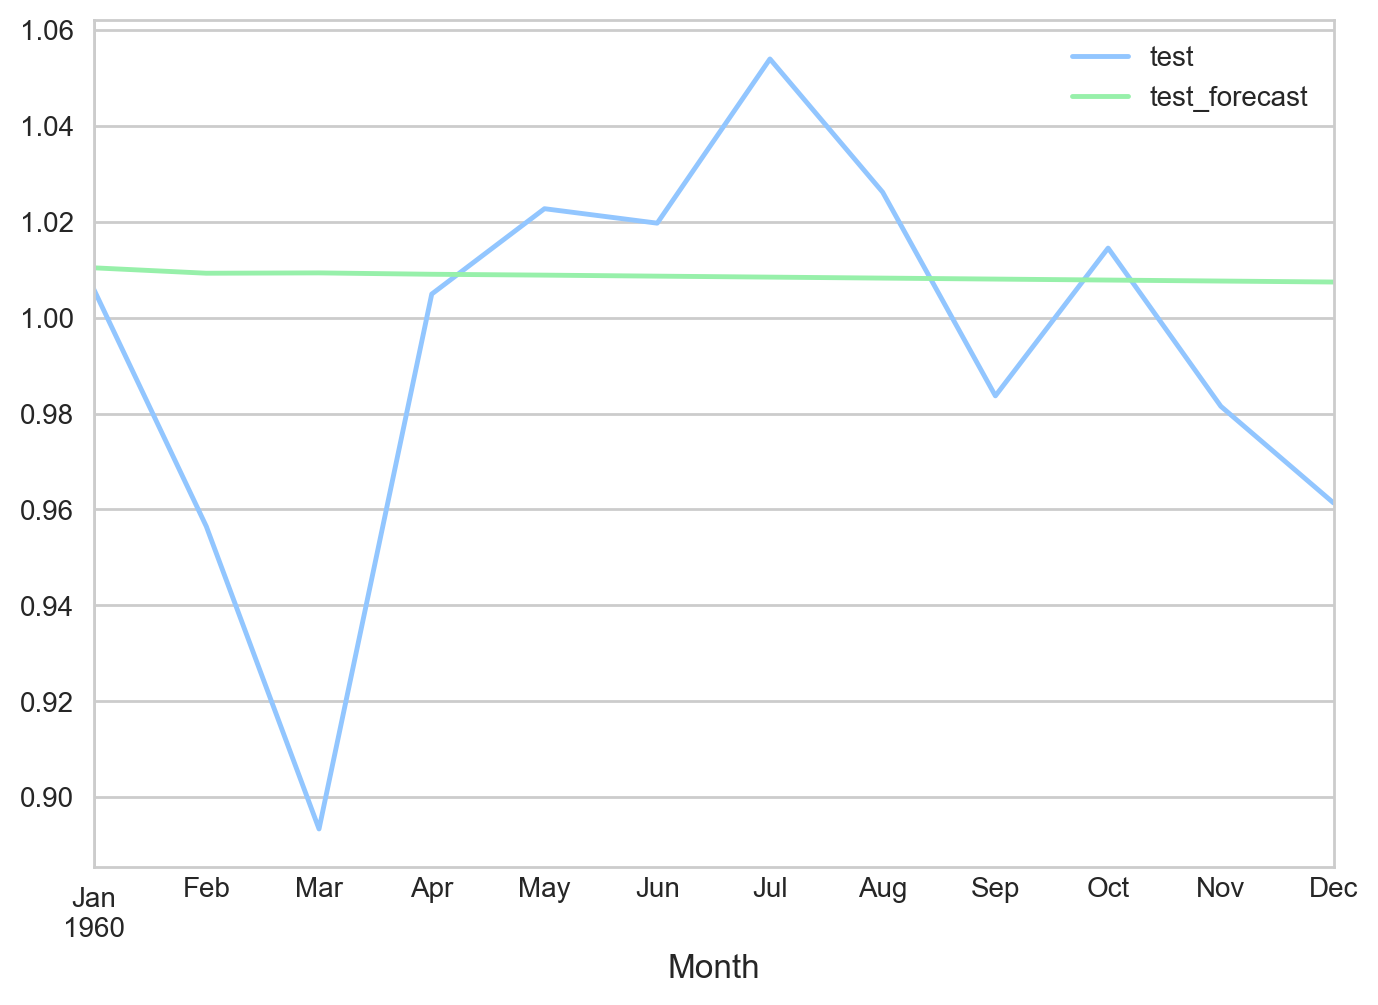

In [118]:
model = ARIMA(train, order=(p, d, q), missing="drop", trend="n")
fitted_model = model.fit()

forecast_1960 = fitted_model.forecast(steps=len(test))

test_results = pd.DataFrame(columns=["test", "test_forecast"])
test_results["test"] = np.exp(test)
test_results["test_forecast"] = np.exp(forecast_1960)

test_results.plot();

In [119]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error

print("MSE", mean_squared_error(test_results["test"], test_results["test_forecast"]))
print("RMSE", root_mean_squared_error(test_results["test"], test_results["test_forecast"]))
print("MAPE", mean_absolute_percentage_error(test_results["test"], test_results["test_forecast"]))

MSE 0.00186691315754562
RMSE 0.04320779047284899
MAPE 0.03201753415075451
